In [2]:
import pickle
with open(r'D:\Intelligent-Support-Ticket\Project Implementation\RAG\final_documnets.pkl' ,'rb') as f:
    documents = pickle.load(f)

In [4]:
len(documents)

381

In [5]:
from langchain_ollama import ChatOllama,OllamaEmbeddings

c:\Users\LOQ\anaconda3\envs\rag_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
llm = ChatOllama(model="qwen2.5:7b",temperature=0.0)
embeddings = OllamaEmbeddings(model='nomic-embed-text')

In [7]:
from langchain_community.vectorstores import Chroma
vectorDB = Chroma.from_documents(documents=documents,embedding=embeddings,collection_name="support_tickets",persist_directory='./chromadb_Agentic')

In [8]:
retriever = vectorDB.as_retriever(
    search_type="mmr",
    search_kwargs={"k": 5, "fetch_k": 20}
)

In [9]:
from langchain_community.retrievers import BM25Retriever
from langchain_classic.retrievers.ensemble import EnsembleRetriever
bm25 = BM25Retriever.from_documents(documents)
bm25.k = 5 

In [10]:
hybrid_retriever = EnsembleRetriever(
    retrievers=[bm25, retriever],
    weights=[0.4, 0.6]
)

In [11]:
hybrid_retriever.invoke("I can not Log in my account ")

[Document(metadata={'category': 'account_password_issue', 'ticket_id': '2'}, page_content='\n    Category: account_password_issue\n    content=\'Issue:\\nThe user is currently unable to log in to their account, reporting that their password is not being accepted. This suggests a potential issue with password authentication, which could stem from several factors, including a simple typo, a forgotten password, or a more complex system error. Further investigation is needed to determine the root cause of this login failure.\\n\\nResolution:\\nThe user should first attempt to reset their password using the "Forgot Password" functionality, if available. If password reset is unsuccessful or unavailable, the user should verify that Caps Lock is off and that they are entering the password correctly. If the issue persists after these steps, a support representative should manually verify the user\\\'s account status and password in the system, ensuring it is active and correctly stored.\' addit

In [37]:
from langgraph.graph import StateGraph, END
from typing import TypedDict, Annotated, Sequence
from langchain_core.messages import BaseMessage, SystemMessage, HumanMessage, ToolMessage
from operator import add as add_messages
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode

In [13]:
import re

def extract_issue_resolution(text: str):
    issue = ""
    resolution = ""

    # Clean weird wrapping
    text = text.replace("content='", "").replace("'", "").strip()

    # Regex extraction (more reliable)
    issue_match = re.search(r"Issue:\s*(.*?)\s*Resolution:", text, re.DOTALL)
    resolution_match = re.search(r"Resolution:\s*(.*)", text, re.DOTALL)

    if issue_match:
        issue = issue_match.group(1).strip()

    if resolution_match:
        resolution = resolution_match.group(1).strip()

    return issue, resolution

In [14]:
@tool
def retriever_tool(query: str) -> str:
    """
    Retrieves relevant support tickets and returns structured Issue/Resolution.
    """

    docs = hybrid_retriever.invoke(query)

    if not docs:
        return "No relevant support tickets found."

    results = []

    for i, doc in enumerate(docs):
        category = doc.metadata.get("category", "Unknown")
        ticket_id = doc.metadata.get("ticket_id", "N/A")

        issue, resolution = extract_issue_resolution(doc.page_content)

        results.append(
            f"""Ticket {i+1}:
Category: {category}
Ticket ID: {ticket_id}

Issue:
{issue}

Resolution:
{resolution}
"""
        )

    return "\n\n".join(results)

In [50]:
tools = [retriever_tool]

llm = llm.bind_tools(tools)

In [51]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

In [52]:
def should_continue(state: AgentState):
    last_message = state["messages"][-1]
    return hasattr(last_message, "tool_calls") and len(last_message.tool_calls) > 0

In [57]:
system_prompt = """
You are a support assistant that helps customer support agents handle user issues using a ticket knowledge base.

You have access to a retrieval tool that returns relevant support tickets containing Issue and Resolution sections.

Rules:
- Always use the retrieval tool for support-related questions when needed
- Base your answers only on retrieved tickets
- Do not make up information
- You may call the tool multiple times if necessary

When responding:
- Analyze the user’s issue as a support agent would
- Identify relevant Issue(s) from past tickets
- Use the corresponding Resolution(s) to suggest how the agent should handle the case
- Provide a clear, structured, and actionable recommendation for the support agent

Output should be written as guidance to a customer support agent (not directly to the customer).

If no relevant tickets are found, say:
"I couldn't find relevant information in the support tickets."

Do not mention the tool or retrieval process in your final answer.
"""

In [58]:
def call_llm(state: AgentState) -> AgentState:
    """Call LLM with system prompt + messages"""
    messages = [SystemMessage(content=system_prompt)] + list(state["messages"])
    response = llm.invoke(messages)
    return {"messages": [response]}

In [59]:
graph = StateGraph(AgentState)
graph.add_node("llm", call_llm)
tool_node = ToolNode(tools)
graph.add_node("tools", tool_node) 

graph.set_entry_point("llm")

graph.add_conditional_edges(
    "llm",
    should_continue,
    {
        True: "tools",
        False: END
    }
)

graph.add_edge("tools", "llm")

rag_agent = graph.compile()

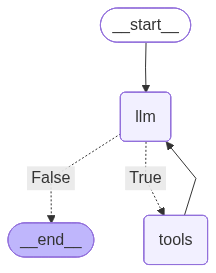

In [60]:
from IPython.display import Image, display

display(
    Image(
        rag_agent.get_graph().draw_mermaid_png()
    )
)

In [68]:
messages = [HumanMessage(content="i feel some suspision log in in my account")]
result = rag_agent.invoke({"messages": messages})
print(result['messages'][-1].content)     

Based on the retrieved support tickets, here is a structured recommendation for handling the user's concern about suspicious login activity:

1. **Immediate Action:**
   - Advise the user to immediately change their account password to a strong, unique one.
   - Enable two-factor authentication (2FA) if it’s not already active.

2. **Review Recent Activity:**
   - Instruct the user to review recent account activity for any other suspicious logins or changes.

3. **Secure Account Further:**
   - Suggest logging out of all devices and sessions to ensure only trusted devices remain connected.
   - If available, recommend enabling additional security features such as biometric authentication or hardware tokens.

4. **Report Incident:**
   - Encourage the user to report the incident to the platform’s support team for further investigation and assistance in securing their account.

5. **Prevent Future Incidents:**
   - Remind the user to regularly update their password and enable 2FA as a st

In [69]:
result

{'messages': [HumanMessage(content='i feel some suspision log in in my account', additional_kwargs={}, response_metadata={}),
  AIMessage(content="Based on the user's concern about suspicious login activity, I recommend analyzing past support tickets to find relevant issues and resolutions. \n\n", additional_kwargs={}, response_metadata={'model': 'qwen2.5:7b', 'created_at': '2026-04-18T17:35:58.0565613Z', 'done': True, 'done_reason': 'stop', 'total_duration': 1451684000, 'load_duration': 286968200, 'prompt_eval_count': 333, 'prompt_eval_duration': 166549100, 'eval_count': 51, 'eval_duration': 925705500, 'logprobs': None, 'model_name': 'qwen2.5:7b', 'model_provider': 'ollama'}, id='lc_run--019da1a9-dabb-7823-b8b3-7bb7a0e63202-0', tool_calls=[{'name': 'retriever_tool', 'args': {'query': 'suspicious login activity'}, 'id': 'ed3345af-62f7-4754-9dbc-ba11998121bc', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 333, 'output_tokens': 51, 'total_tokens': 384}),
 

In [1]:
def get_agentic_answer(question):
    messages = [HumanMessage(question)]

    result = rag_agent.invoke({"messages": messages})
    return result['messages'][-1].content

In [20]:
from langchain_community.vectorstores import Chroma
from langchain_ollama import OllamaEmbeddings

def load_vectorstore():
    embedding = OllamaEmbeddings(model='nomic-embed-text')

    vectordb = Chroma(
        persist_directory=r"D:\Intelligent-Support-Ticket\Project Implementation\Agentic_RAG\chromadb_Agentic",
        embedding_function=embedding,
        collection_name="support_tickets"
    )

    return vectordb

In [21]:
vectorDB = load_vectorstore()

retriever = vectorDB.as_retriever(
    search_type="mmr",
    search_kwargs={"k": 5, "fetch_k": 20}
)

In [7]:
import pickle
with open(r'D:\Intelligent-Support-Ticket\Project Implementation\RAG\final_documnets.pkl' ,'rb') as f:
    documents = pickle.load(f)

In [8]:
from langchain_community.retrievers import BM25Retriever
from langchain_classic.retrievers.ensemble import EnsembleRetriever
bm25 = BM25Retriever.from_documents(documents)
bm25.k = 5 

In [24]:
hybrid_retriever = EnsembleRetriever(
    retrievers=[bm25, retriever],
    weights=[0.4, 0.6]
)

In [25]:
hybrid_retriever.invoke("I can not Log in ")

[Document(metadata={'category': 'permissions_issue', 'ticket_id': '364'}, page_content='\n    Category: permissions_issue\n    content=\'Issue:\\nThe Microsoft Teams application consistently crashes when the user attempts to join a scheduled meeting or call. This issue occurs immediately upon selecting the "Join" option, preventing any participation in audio or video sessions. The behavior is reproducible across multiple call attempts.\\n\\nResolution:\\nBegin by ensuring the Teams application is updated to the latest version through the official client or store. If the problem persists, perform a clean reinstall of the application after clearing local cache files. Finally, verify that the device meets the minimum system requirements for running Teams, including sufficient memory and compatible operating system versions.\' additional_kwargs={} response_metadata={\'token_usage\': {\'completion_tokens\': 626, \'prompt_tokens\': 192, \'total_tokens\': 818, \'completion_tokens_details\': {